In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

In [15]:
data = deliveries.merge(
    matches[['id','season']],
    left_on='match_id',
    right_on='id'
)

In [16]:
innings_score = data.groupby(
    ['season','match_id','inning']
)['total_runs'].sum().reset_index()

In [17]:
season_avg = innings_score.groupby('season')['total_runs'].mean().reset_index()
season_avg

,season,total_runs
0,2007/08,154.629310
1,2009,140.974138
2,2009/10,154.778689
3,2011,145.889655
4,2012,151.709459
5,2013,144.884615
6,2014,155.172131
7,2015,154.226891
8,2016,157.183333
9,2017,156.550000


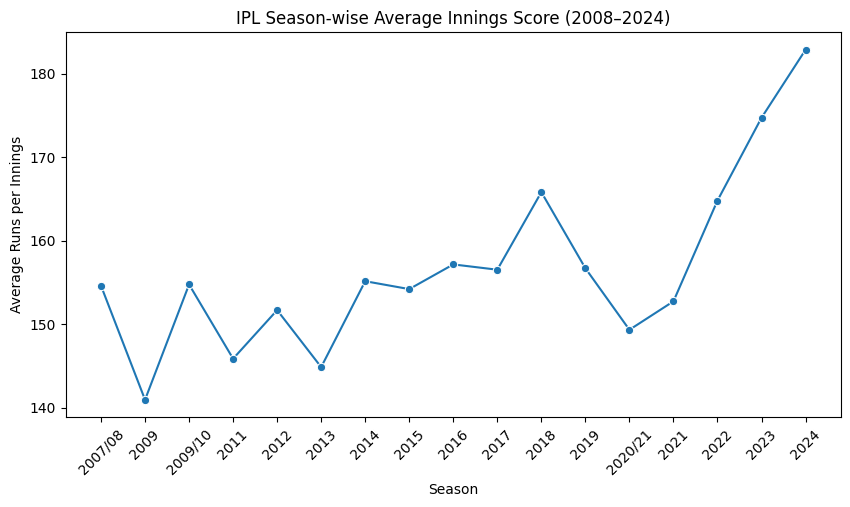

In [18]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=season_avg,
    x='season',
    y='total_runs',
    marker='o'
)

plt.title("IPL Season-wise Average Innings Score (2008–2024)")
plt.xlabel("Season")
plt.ylabel("Average Runs per Innings")
plt.xticks(rotation=45)
plt.show()

Last five years the avg score will be increasing due to batting factor

In [19]:
data = deliveries.merge(
    matches[['id','season']],
    left_on='match_id',
    right_on='id'
)

In [20]:
sixes = data[data['batsman_runs'] == 6]

In [21]:
season_sixes = sixes.groupby('season').size().reset_index(name='total_sixes')
season_sixes

,season,total_sixes
0,2007/08,623
1,2009,508
2,2009/10,587
3,2011,639
4,2012,733
5,2013,681
6,2014,715
7,2015,692
8,2016,639
9,2017,706


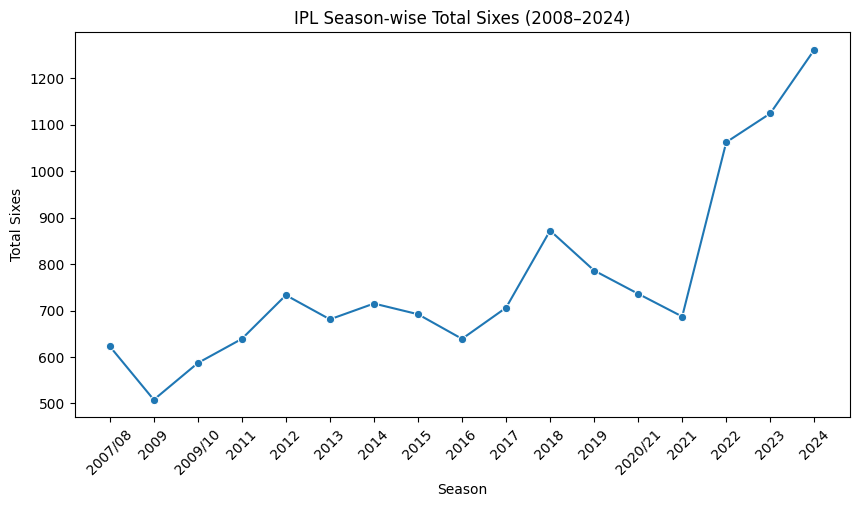

In [22]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=season_sixes,
    x='season',
    y='total_sixes',
    marker='o'
)

plt.title("IPL Season-wise Total Sixes (2008–2024)")
plt.xlabel("Season")
plt.ylabel("Total Sixes")
plt.xticks(rotation=45)
plt.show()

IPL six hitting has increased over the years,
showing modern cricket is more aggressive and power-hitting oriented.

In [23]:
match_runs = data.groupby(
    ['season','match_id']
)['total_runs'].sum().reset_index()

In [24]:
match_runs['run_rate'] = match_runs['total_runs'] / 40

In [25]:
season_rr = match_runs.groupby('season')['run_rate'].mean().reset_index()
season_rr

,season,run_rate
0,2007/08,7.731466
1,2009,7.172368
2,2009/10,7.867917
3,2011,7.244521
4,2012,7.585473
5,2013,7.434868
6,2014,7.887917
7,2015,7.776695
8,2016,7.859167
9,2017,7.960169


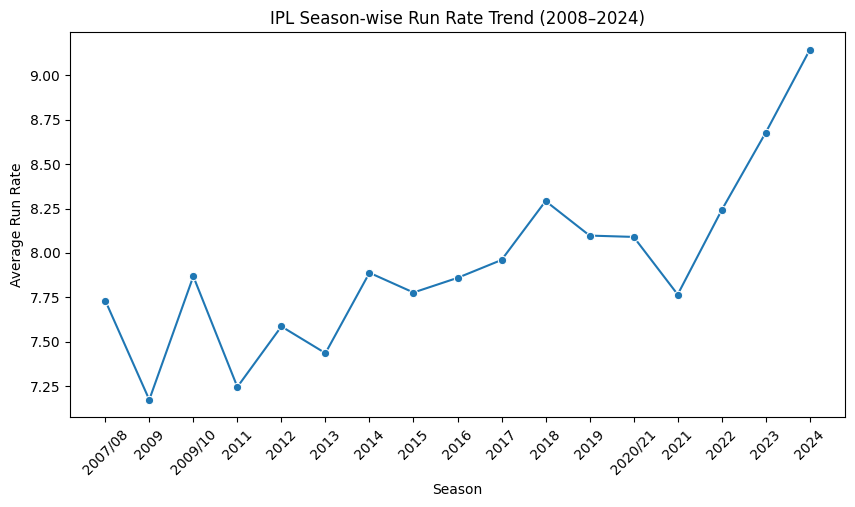

In [26]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=season_rr,
    x='season',
    y='run_rate',
    marker='o'
)

plt.title("IPL Season-wise Run Rate Trend (2008–2024)")
plt.xlabel("Season")
plt.ylabel("Average Run Rate")
plt.xticks(rotation=45)
plt.show()

IPL run rate has increased over the years,
showing faster scoring and more aggressive batting in modern seasons.

In [27]:
bowler_stats = data.groupby(
    ['season','bowler']
).agg(
    runs_conceded=('total_runs','sum'),
    balls=('ball','count')
).reset_index()

In [28]:
bowler_stats['economy'] = (bowler_stats['runs_conceded'] / bowler_stats['balls']) * 6

In [29]:
season_economy = bowler_stats.groupby('season')['economy'].mean().reset_index()
season_economy

,season,economy
0,2007/08,8.748582
1,2009,7.691484
2,2009/10,8.498261
3,2011,8.516908
4,2012,8.630517
5,2013,7.861282
6,2014,8.610885
7,2015,8.453344
8,2016,8.292297
9,2017,8.851204


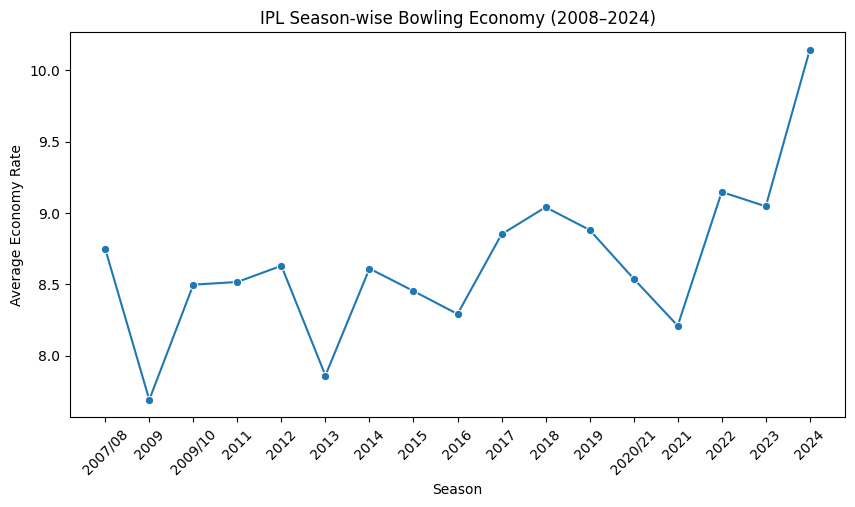

In [30]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=season_economy,
    x='season',
    y='economy',
    marker='o'
)

plt.title("IPL Season-wise Bowling Economy (2008–2024)")
plt.xlabel("Season")
plt.ylabel("Average Economy Rate")
plt.xticks(rotation=45)
plt.show()

Bowling economy has increased slightly over years,
showing that modern IPL is more batting-friendly.